##Diksha Maharjan
#2408235


# Implementation of MCP Neuron for AND and OR Function.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)
  ### YOUR CODE HERE ###

  # Create a new array to put all the prediction let's name that a state_neuron.
  state_neuron=[]

  for i in range(len(X1)):
    #sum of inputs for the current index
        z = X1[i] + X2[i]

  # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
        if z >= T:
            # Action (indented twice)
            state_neuron.append(1)
        else:
            # Action (indented twice)
            state_neuron.append(0)
  return state_neuron

In [ ]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
    ### YOUR CODE HERE ###
    # Create a new array to put all the prediction let's name that a state_neuron.
    state_neuron=[]

    # Perform an element wise addition of two input arrays stored in a new array(list):
    for i in range(len(X1)):
        # Calculate the sum for the current index
        z = X1[i] + X2[i]
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
    if z >= T:
            state_neuron.append(1)
    else:
          state_neuron.append(0)
    return state_neuron


In [ ]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [1]


#Question - 1: List out all the limitations of MCP - Neurons.
- MCP NEURON can handle binary classifications such that linearly separable solutions.
- it doesnot have learning mechanism like how advanced neural networks have as weights and thresholds are defined manually.


#Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
- MCP Neuron is a liner classifier so, it becomes easier to separate 1 output from 0s such that and & or gates can be formed through this model but for XOR, 1s are at 0.1 and 1.0 while 0s are at 0,0 and 1,1 which is why we cannot draw a straight line to separate these groups. In simple words, XOR is linearly inseparable so, MCP cannot do this task.


# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/sem6/week3/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


### Viewing the Dataset.

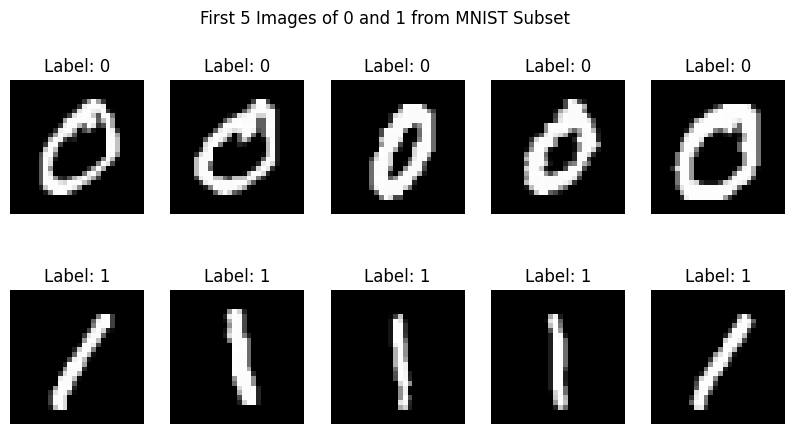

In [ ]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

# Question - 3: What does the weights array represent in this context?
- here, we are taking the shape of the image such that all the pixels are taken as weights in this context. As the image when flattened 28*28 784 pixels, so we create 784 weights having array to match it perfectly,

# Question - 4: Why are we initializing the weights to zero? What effect could this have on the training process?
- initially all neurons are blind, and we are setting all weights to 0, this way, no pixel becomes more important than other. Bias is also initialised to 0, now, dot product of pixel with weight is taken for each oneand summation of those products and bias is taken, and with that learning phase starts, adjust ment is done, with several epoch or iterations, weights will not be 0 and they will have taken a shape that looks like that of the digit in the image.

- For example, if we are training it to recognize the number "0", the weights in the center of the 28x28 grid will likely become negative (because a "0" is empty in the middle), while the weights forming the circle will become positive.

- hence, having 0 as initialised weights ensures neutrality to all pixels.

## Step - 3 - Make a Decision function:

In [ ]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############  # Activation function (step function)
    # np.where returns 1 if the condition is met, and 0 otherwise
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    # Your Code here#
    n_samples = X.shape[0]

    for epoch in range(epochs):
        accuracy = 0
        for i in range(n_samples):
            # Calculate the linear combination (z = Xw + b)
            linear_output = np.dot(X[i], weights) + bias

            # Activation function (Step function: 1 if >= 0, else 0)
            y_pred = 1 if linear_output >= 0 else 0

            # Check if prediction is correct
            if y_pred == y[i]:
                accuracy += 1
            else:
                # Update rule: W = W + learning_rate * (y_true - y_pred) * X
                update = learning_rate * (y[i] - y_pred)
                weights += update * X[i]
                bias += update

        # Optional: Stop early if 100% accuracy is reached
        if accuracy == n_samples:
            break

    return weights, bias, accuracy

#Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?
- this formula is needed to find the weighted sum, it finds the deviation from the expected output, suc that weighted sum is a large positive number then many important pixels are active and vice versa. it acts like a performance score judge. this formula is meant to compare and see how well our model is doing with each iter.

#Question - 6: What happens when the prediction is wrong? How are the weights and bias updated?
- If the neuron should have fired but stayed silent (Target = 1, Prediction = 0), it becomes more sensitive. It looks at the pixels that were active in that image and increases their weights. This ensures that the next time it sees those same pixels, the total score will be higher.

- If the neuron fired by mistake (Target = 0, Prediction = 1), it does the opposite. It decreases the weights of the pixels that were active, making it less likely to fire for that specific pattern again. The bias also moves up or down to change the overall threshold. By using a small learning rate (0.1), the neuron makes small, steady changes rather than one giant, sudden change.

#Question - 7:Why is the final accuracy important, and what do you expect it to be?
- Why it matters: Accuracy is the final measurement of how well the neuron learned. It shows the percentage of images the model correctly identified after 100 rounds of practice.

- What to expect: For a single neuron, you should expect an accuracy between 85% and 92%. It will not reach 100% because a single neuron uses "linear logic," and some handwritten numbers (like a messy 4 and a 9) are too similar for such a simple tool to distinguish perfectly.

## Training the Perceptron

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  12665


## Step 5: Visualize Misclassified Images

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


# Question - 8:What does misclassified idx store, and how is it used in this code?
- Imagine you show the neuron 10 images: five are "0s" and five are "1s." If the neuron correctly identifies eight of them but fails on the 3rd and 7th images, the misclassified_idx will store the numbers [2, 6] (remembering that Python starts counting at zero).

- This list is a collection of specific failures. By storing these two numbers, you can go back to your original folder of images and pull out exactly what those two pictures look like. You might discover that the "0" was drawn so thin it looked like a "1," or the "1" had a large base that made it look like a "0." It allows you to see exactly where your "weighted sum" math failed to reach the correct score.

# Question - 9: How do you interpret the result if the output is ”All images were correctly classified!”?
- If the output says "All images were correctly classified!", it means your neuron found a perfect balance of weights and bias to separate every "0" from every "1."

- here, it means the neuron successfully created a "template" where every single "0" resulted in a score below the threshold and every single "1" resulted in a score above it. This tells you the two groups are linearly separable—mathematically, you could draw a single straight line on a graph with "0s" on one side and "1s" on the other. While this is common in very simple tests, it is rare in large datasets because human handwriting is often inconsistent and messy.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/sem6/week3/mnist_3_and_5.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


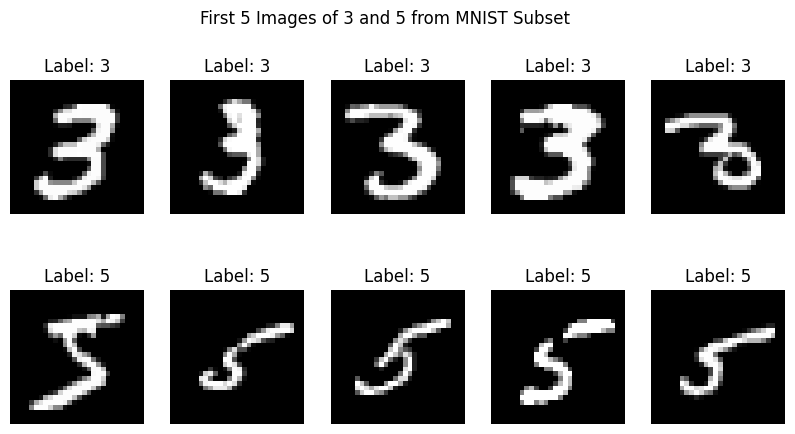

In [ ]:
# 1. Correct the filtering
images_3 = X[y == 3]
images_5 = X[y == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# 2. Update the check to look at the new variables
if len(images_3) < 5 or len(images_5) < 5:
    print(f"Error: Not enough images. Found {len(images_3)} 3s and {len(images_5)} 5s.")
else:
    for i in range(5):
        # 3. Plot digit 3 (Top Row)
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        # 4. Plot digit 5 (Bottom Row)
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
    plt.show()

In [ ]:
# Initialize weights and bias for 3 vs 5 classification
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

In [ ]:
# Train the perceptron for 3 vs 5 classification
# Note: The y labels in the dataset are 3 and 5. The perceptron expects 0 and 1.
# So, we need to map the labels: 3 -> 0 and 5 -> 1 for training.
y_mapped = np.where(y == 3, 0, 1)

weights_3_5, bias_3_5, accuracy_3_5 = train_perceptron(X, y_mapped, weights.copy(), bias, learning_rate, epochs)

# Evaluate the model using the new function
print(f"The Final Accuracy for 3 vs 5 classification is: {accuracy_3_5 / len(y_mapped):.4f}")

The Final Accuracy for 3 vs 5 classification is: 0.9858


Final Accuracy: 0.9869
Number of misclassified images: 36


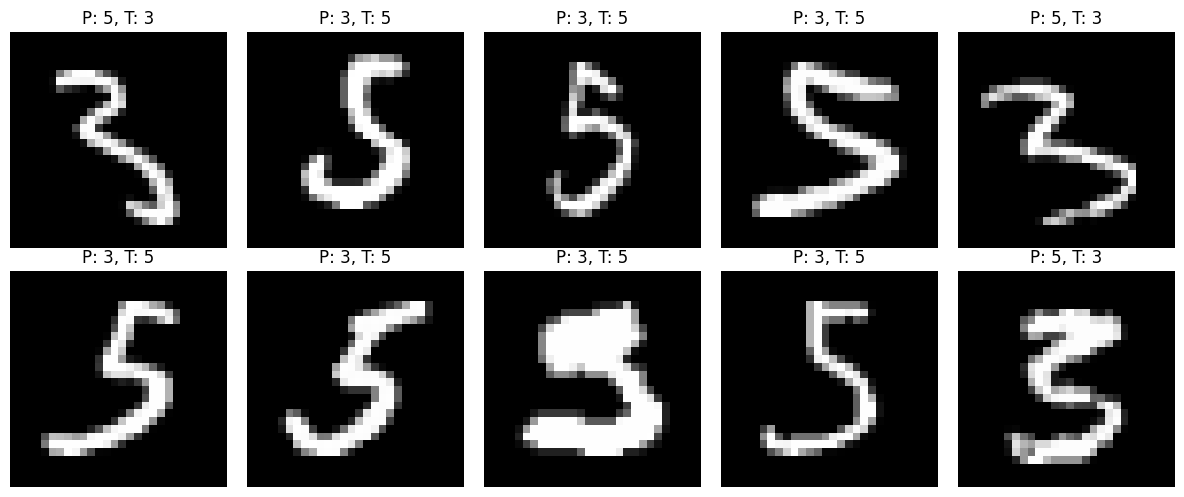

In [ ]:
# Map original labels to binary (3 becomes 0, 5 becomes 1)
y_mapped = np.where(y == 3, 0, 1)

# Train using the mapped labels
weights_3_5, bias_3_5, accuracy_count = train_perceptron(X, y_mapped, weights.copy(), bias, learning_rate, epochs)

# Get predictions (binary: 0 or 1)
linear_output = np.dot(X, weights_3_5) + bias_3_5
y_pred_binary = np.where(linear_output >= 0, 1, 0)

# Calculate real accuracy (compare binary to binary)
final_accuracy = np.mean(y_pred_binary == y_mapped)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Identify misclassified indices
misclassified_idx = np.where(y_pred_binary != y_mapped)[0]
print(f"Number of misclassified images: {len(misclassified_idx)}")

# Visualize (if there are errors)
if len(misclassified_idx) > 0:
    plt.figure(figsize=(12, 5))
    num_to_show = min(len(misclassified_idx), 10)

    for i in range(num_to_show):
        idx = misclassified_idx[i]
        plt.subplot(2, 5, i + 1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")

        # Map back to 3 and 5 just for the title
        actual = y[idx]
        pred = 3 if y_pred_binary[idx] == 0 else 5

        plt.title(f"P: {pred}, T: {actual}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Perfect classification! No errors to show.")